# R₀ Calculation for SEIRS-SEI Model

Deriving the basic reproduction number $R_0$ using the Next Generation Matrix (NGM) approach.

## 1. Model Equations

### Human (SEIRS):
$$\frac{dS_H}{dt} = - a b_2 \frac{I_M(t)}{N} S_H + \omega R_H$$
$$\frac{dE_H}{dt} = a b_2 \frac{I_M(t)}{N} S_H - b_{3H} E_H$$
$$\frac{dI_H}{dt} = b_{3H} E_H - \gamma I_H$$
$$\frac{dR_H}{dt} = \gamma I_H - \omega R_H$$

### Mosquito (SEI):
$$\frac{dS_M}{dt} = \Lambda - a b_1 \frac{I_H(t)}{N} S_M - \mu S_M$$
$$\frac{dE_M}{dt} = a b_1 \frac{I_H(t)}{N} S_M - (\mu + b_{3M}\ell) E_M$$
$$\frac{dI_M}{dt} = b_{3M}\ell E_M - \mu I_M$$

<!--where $\ell = e^{-\mu \tau_M}$ is the probability of surviving the sporogonic delay.-->

**Note:** Force of infection uses **current** values for new exposures, progression to infectious uses **delayed** values.

**Mosquito recruitment:**
$$\Lambda = b(R,T) \cdot K \cdot \left(1 - \frac{S_M + E_M + I_M}{K}\right)$$

**Parameters:**
<!-- - $r_H$: Human net growth rate -->
- $a$: Mosquito biting rate
- $b_1$: Probability of transmitting from human to mosquito
- $b_2$: Probability of transmitting from mosquito to human
- $\tau_H$: Human incubation period
- $\tau_M$: Sporogonic delay
- $b_3$: Delay approximation
    - $b_{3H} = \dfrac{1}{\tau_H}$
    - $b_{3M} = \dfrac{T(T-T_{\min\text{Plasm.}})\sqrt{T_{\max\text{Plasm.}}-T}}{DD(T_{\text{opt Plasm.}})\sqrt{T_{\max\text{Plasm.}}-T_{\text{opt Plasm.}}}}$
- $\ell = e^{-\mu \tau_M}$: Probability of surviving sporogony
- $b(R,T)$: Temperature/rain dependent recruitment
- $K$: Mosquito carrying capacity: $K = M \times $ Temperature factor $ \times $ Rain factor $ \times $ Seasonal factor
  - Temperature factor: $\min\left(1, \dfrac{T(T-T_{\min\text{A.}})\sqrt{T_{\max\text{A.}}-T}}{T_{\text{opt A.}}(T_{\text{opt A.}}-T_{\min\text{A.}})\sqrt{T_{\max\text{A.}}-T_{\text{opt A.}}}}\right) $   <!-- $\max\left(0.1, \min\left(1, \dfrac{T - 15}{15}\right)\right)$ -->
  - Rain factor: $\dfrac{2R}{R_L}\exp\left(1 - \dfrac{2R}{R_L} \right)$   <!-- $\min\left(1, \max\left(0, \dfrac{R}{30}\right)\right)$-->
  <!-- - Seasonal factor: $2.5 + 2\sin\left(2\pi\dfrac{t - 180}{365.25}\right) \ (1\leq t \leq 366)$-->
- $\mu$: Mosquito mortality rate
- $\omega$: Immunity loss rate
- $\gamma$: Recovery rate

## 2. Next Generation Matrix Approach

**Infected compartments:** $[E_H, I_H, E_M, I_M]$

Define:
- $\mathcal{F}$: rate of new infections
- $\mathcal{V} = \mathcal{V}^{-} - \mathcal{V}^{+}$: rate of transitions out minus in

At the **Disease-Free Equilibrium (DFE)**:
- $S_H^* = N, E_H^* = I_H^* = R_H^* = 0$
- $S_M^* = \Lambda/\mu, E_M^* = I_M^* = 0 \Longrightarrow S_M^* = b(R,T)\cdot K\cdot\left(1-\frac{S_M^*}{K}\right)/\mu \Longrightarrow S_M^* =\frac{bK}{b+\mu}$

Then $R_0 = \rho(FV^{-1})$

## 3. Computing $\mathcal{F}$ and $\mathcal{V}$
### $\mathcal{F}$ (New Infections)
Only terms that create **newly infected** individuals:
- $\mathcal{F}_1 = a b_2 \frac{I_M}{N} S_H$ → at DFE: $a b_2 I_M$
- $\mathcal{F}_2 = 0$
- $\mathcal{F}_3 = a b_1 \frac{I_H}{N} S_M$ → at DFE: $a b_1 \frac{(\Lambda/\mu)}{N} I_H$
- $\mathcal{F}_4 = 0$
### $\mathcal{V} = \mathcal{V}^{-} - \mathcal{V}^{+}$
Using transition rates $b_{3H} = 1/\tau_H$ and $b_{3M}\ell \approx 1/\tau_M$:
- **For $E_H$ (exposed humans):**
  - $\mathcal{V}_1^{-} = b_{3H} E_H$ (progression to $I_H$)
  - $\mathcal{V}_1^{+} = 0$
  - $\mathcal{V}_1 = b_{3H} E_H$
- **For $I_H$ (infectious humans):**
  - $\mathcal{V}_2^{-} = \gamma I_H$ (recovery)
  - $\mathcal{V}_2^{+} = b_{3H} E_H$ (inflow from $E_H$)
  - $\mathcal{V}_2 = \gamma I_H - b_{3H} E_H$
- **For $E_M$ (exposed mosquitoes):**
  - $\mathcal{V}_3^{-} = b_{3M}\ell E_M + \mu E_M$ (progression to $I_M$ + death)
  - $\mathcal{V}_3^{+} = 0$
  - $\mathcal{V}_3 = (b_{3M}\ell + \mu) E_M$
- **For $I_M$ (infectious mosquitoes):**
  - $\mathcal{V}_4^{-} = \mu I_M$ (death)
  - $\mathcal{V}_4^{+} = b_{3M}\ell E_M$ (inflow from $E_M$)
  - $\mathcal{V}_4 = \mu I_M - b_{3M}\ell E_M$

## 4. Jacobians at DFE
### Computing F from $\mathcal{F}$
$\mathcal{F} = (\mathcal{F}_1, \mathcal{F}_2, \mathcal{F}_3, \mathcal{F}_4)$ 
where:
- $\mathcal{F}_1 = a b_2 \frac{I_M}{N} S_H$
- $\mathcal{F}_3 = a b_1 \frac{I_H}{N} S_M$
Partial derivatives at DFE ($S_H = N, S_M = \Lambda/\mu$):
$$F = \frac{\partial \mathcal{F}}{\partial (E_H, I_H, E_M, I_M)} = \begin{pmatrix} \frac{\partial \mathcal{F}_1}{\partial E_H} & \frac{\partial \mathcal{F}_1}{\partial I_H} & \frac{\partial \mathcal{F}_1}{\partial E_M} & \frac{\partial \mathcal{F}_1}{\partial I_M} \\\frac{\partial \mathcal{F}_2}{\partial E_H} & \frac{\partial \mathcal{F}_2}{\partial I_H} & \frac{\partial \mathcal{F}_2}{\partial E_M} & \frac{\partial \mathcal{F}_2}{\partial I_M} \\\frac{\partial \mathcal{F}_3}{\partial E_H} & \frac{\partial \mathcal{F}_3}{\partial I_H} & \frac{\partial \mathcal{F}_3}{\partial E_M} & \frac{\partial \mathcal{F}_3}{\partial I_M} \\\frac{\partial \mathcal{F}_4}{\partial E_H} & \frac{\partial \mathcal{F}_4}{\partial I_H} & \frac{\partial \mathcal{F}_4}{\partial E_M} & \frac{\partial \mathcal{F}_4}{\partial I_M}\end{pmatrix} = \begin{pmatrix} 0 & 0 & 0 & a b_2 \\0 & 0 & 0 & 0 \\0 & a b_1 \frac{(\Lambda/\mu)}{N} & 0 & 0 \\0 & 0 & 0 & 0\end{pmatrix}$$
### Computing V from $\mathcal{V}$
$\mathcal{V} = (\mathcal{V}_1, \mathcal{V}_2, \mathcal{V}_3, \mathcal{V}_4)$ 
where:
- $\mathcal{V}_1 = b_{3H} E_H$
- $\mathcal{V}_2 = \gamma I_H - b_{3H} E_H$
- $\mathcal{V}_3 = (b_{3M}\ell + \mu) E_M$
- $\mathcal{V}_4 = \mu I_M - b_{3M}\ell E_M$
Partial derivatives
:$$V = \frac{\partial \mathcal{V}}{\partial (E_H, I_H, E_M, I_M)} = \begin{pmatrix} \frac{\partial \mathcal{V}_1}{\partial E_H} & \frac{\partial \mathcal{V}_1}{\partial I_H} & \frac{\partial \mathcal{V}_1}{\partial E_M} & \frac{\partial \mathcal{V}_1}{\partial I_M} \\\frac{\partial \mathcal{V}_2}{\partial E_H} & \frac{\partial \mathcal{V}_2}{\partial I_H} & \frac{\partial \mathcal{V}_2}{\partial E_M} & \frac{\partial \mathcal{V}_2}{\partial I_M} \\\frac{\partial \mathcal{V}_3}{\partial E_H} & \frac{\partial \mathcal{V}_3}{\partial I_H} & \frac{\partial \mathcal{V}_3}{\partial E_M} & \frac{\partial \mathcal{V}_3}{\partial I_M} \\\frac{\partial \mathcal{V}_4}{\partial E_H} & \frac{\partial \mathcal{V}_4}{\partial I_H} & \frac{\partial \mathcal{V}_4}{\partial E_M} & \frac{\partial \mathcal{V}_4}{\partial I_M}\end{pmatrix} = \begin{pmatrix} b_{3H} & 0 & 0 & 0 \\-b_{3H} & \gamma & 0 & 0 \\0 & 0 & b_{3M}\ell + \mu & 0 \\0 & 0 & -b_{3M}\ell & \mu\end{pmatrix}$$

**Determinant:** $\det(V) = b_{3H} \cdot \gamma \cdot \mu \cdot (b_{3M}\ell + \mu) > 0$, so V is **invertible**.

## 5. Next Generation Matrix
$K = F V^{-1}$
**Human block inversion:**
$$V_H = \begin{pmatrix} b_{3H} & 0 \\ -b_{3H} & \gamma \end{pmatrix}, \quad V_H^{-1} = \begin{pmatrix} \frac{1}{b_{3H}} & 0 \\ \frac{1}{\gamma} & \frac{1}{\gamma} \end{pmatrix}$$
**Mosquito block inversion:**
$$V_M = \begin{pmatrix} b_{3M}\ell+\mu & 0 \\ -b_{3M}\ell & \mu \end{pmatrix}, \quad V_M^{-1} = \begin{pmatrix} \frac{1}{b_{3M}\ell+\mu} & 0 \\ \frac{b_{3M}\ell}{(b_{3M}\ell+\mu)\mu} & \frac{1}{\mu} \end{pmatrix}$$
**NGM:**
$$K = F V^{-1} = \begin{pmatrix} 0 & 0 & \frac{a b_2 b_{3M}\ell}{(b_{3M}\ell+\mu)\mu} & \frac{a b_2}{\mu} \\0 & 0 & 0 & 0 \\\frac{a b_1 \Lambda}{N \gamma \mu} & \frac{a b_1 \Lambda\mu}{N \gamma \mu} & 0 & 0 \\0 & 0 & 0 & 0\end{pmatrix}$$
The characteristic polynomial is $\lambda^4 - \left(\frac{a^2 b_1 b_2 \Lambda}{N \gamma \mu} \cdot \frac{b_{3M}\ell}{(b_{3M}\ell+\mu)\mu}\right) \lambda^2 = 0$

The eigenvalues are $0, 0, \pm \sqrt{\frac{a^2 b_1 b_2 \Lambda}{N \gamma \mu} \cdot \frac{b_{3M}\ell}{(b_{3M}\ell+\mu)\mu}}$

## 6. Final R₀ Formula

The spectral radius (dominant eigenvalue) is:

$$R_0 = \frac{a}{\mu}\sqrt{\frac{b_1b_2\Lambda b_{3M}\ell}{N\gamma(b_{3M}\ell+\mu)}}$$

where $\ell = e^{-\mu \tau_M}$ is the probability of surviving the sporogonic delay.

This can be written as:

$$R_0 = \sqrt{R_0^{H} \cdot R_0^{M}}$$

where:
- $R_0^{H} = \frac{a b_2}{\gamma}$ (human side contribution)
- $R_0^{M} = \frac{\Lambda a b_1 b_{3M}\ell}{N (b_{3M}\ell+\mu)\mu^2}$ (mosquito side contribution)


## Summary

| Component | Formula |
|-----------|---------|
**Human (SEIRS)** | $R_0^{H} = \frac{a b_2}{\gamma}$ |
**Mosquito (SEI)** | $R_0^{M} = \frac{\Lambda a b_1}{N\mu} \cdot \frac{b_{3M}\ell}{(b_{3M}\ell+\mu)\mu}$ |
**Combined** | $R_0 = \sqrt{R_0^{H} \cdot R_0^{M}}$ |

**Key insights:**
- $\tau_H$ (human incubation) cancels out (no mortality during this period)
- $\tau_M$ (sporogony) appears via $\ell = e^{-\mu \tau_M}$ (mosquito mortality during incubation reduces transmission)

### ________________________________________________________________________________________________________ ###

#### Estimating R0 for the given parameters, and estimating b1, b2 for R0=1:

At this point, we will already consider $T'=16^\circ C$ and $D_1=24.8$, based on the results of data_files/notebooks/Biting_Rate_Estimation.ipynb

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '../../data_files/data'

climate_data = pd.read_csv(DATA_DIR + '/climate_api_data_2016_2024.csv')
cases_data = pd.read_csv(DATA_DIR + '/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv')
pop_data = pd.read_csv(DATA_DIR + '/ibge_manaus_population_data_2016_2024.csv')
pop_data.rename(columns={'index': 'date'}, inplace=True)

# Load IBGE population data (2000-2025) for yearly N
pop_ibge = pd.read_csv(DATA_DIR + '/ibge_manaus_rural_population_data_2000_2025.csv')
pop_by_year = dict(zip(pop_ibge['year'], pop_ibge['rural_population']))

climate_data['date'] = pd.to_datetime(climate_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])
pop_data['date'] = pd.to_datetime(pop_data['date'])

# Filter data to 2017-01-01 to 2023-12-31
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2023-12-31')
climate_data = climate_data[(climate_data['date'] >= start_date) & (climate_data['date'] <= end_date)].reset_index(drop=True)
cases_data = cases_data[(cases_data['date'] >= start_date) & (cases_data['date'] <= end_date)].reset_index(drop=True)
pop_data = pop_data[(pop_data['date'] >= start_date) & (pop_data['date'] <= end_date)].reset_index(drop=True)

In [13]:
#### Model Parameters 
T_prime = 16 #19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 24.8 #36.5
b1 = 0.04
b2 = 0.09
A = -0.03
B = 1.31
C = -4.4
DD = 105
Tmin = 14.5  # critical min temperature for Plasmodium development
gamma = 1/120
R_L = 32.67

# SEIRS parameters
tau_H = 10
omega = 1/365

# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

In [14]:
# Rural cases for initial conditions
rural_cases_df = cases_data.copy()
rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']] = rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']]*(41.54/100)
I_H0 = round(rural_cases_df['active_total'].iloc[0])
### We will estimate that E_H0 represents about 5% of the human population, while R_H0 is ~15%, given the acquired immunity over time
N_2017 = round(pop_by_year[2017])

E_H0 = round(N_2017 * 0.05)
R_H0 = round(N_2017 * 0.15)

S_H0 = N_2017 - E_H0 - I_H0 - R_H0

### As mentioned above, during the month of January, which is the starting month of our analysis, the ratio between female mosquitos to humans
### is, on average, 9.9:
M_0 = 9.9 * N_2017
### We may later optimize M (M_0) to best fit our data
### In addition to that, we would like for our infected population to start decreasing, to better approximate the behavior of 
### the real data. As such, we will pick a value for I_M0 such that \lambda_H < 1 at the start. For that,
### it was decided to use I_M/N = 0.1. E_M0 represents 3 I_M0, as estimated previously.
### We may later optimize I_M0 and E_M0 to best fit our data
I_M0 = round(N_2017 * 0.1)
E_M0 = round(I_M0 * 3)
S_M0 = M_0 - E_M0 - I_M0
initial_state_2017 = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

print(f"Initial human compartments in 2017: N={N_2017}, S_H={S_H0}, E_H={E_H0}, I_H={I_H0}, R_H={R_H0}")
print(f"Initial mosquito compartments in 2017: M={M_0}, S_M={S_M0}, E_M={E_M0}, I_M={I_M0}")

M_prime = 494121 # Fitted M' value for K, estimated by minimizing MSE between I_H and actual cases

Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=82853.1, S_M=79505.1, E_M=2511, I_M=837


In [15]:
### Helper functions using passed parameters
def tau_L(Temp):
    denom = c1 * Temp + c2
    return 1.0/denom if denom > 0 else 100.0

def p_T(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    """Adult survival probability of Anopheles darlingi in the Amazon (Epidbot)
    
    Input:
      H0 = 58: Midpoint of the sigmoid (humidity where p_H ≈ 0.5)
      k = 0.25: Transition slope
      phi = 0.05: Minimum survival (micro-habitats)
    
    NOTE: This should use umid_min (daily minimum), NOT umid_med.
    """
    
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    p_H = phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))
    
    return p_T_temp * p_H

def mu(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    p_val = p_T(Temp, Humid, H0, k, phi)
    return -np.log(p_val) if p_val > 0 else 1.0

def a(Temp):
    return max(0, (Temp - T_prime)/D1)

def tau_M(Temp):
    diff = Temp - Tmin
    return DD/diff if diff > 0 else 1000.0

def b_rate(Rain, Temp):
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0: return 0.0
    p_ER = (4*p_ME/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    p_LR = (4*p_ML/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    p_LT = np.exp(-(c1*Temp + c2))
    p_PR = (4*p_MP/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    numer = B_E * p_ER * p_LR * p_LT * p_PR
    denom = tau_E + tau_L_curr + tau_P
    return numer/denom if denom > 0 else 0.0

def b3_briere_unscaled_plasm(Temp):
    return Temp * (Temp - Tmin) * (critical_max_temp_plasm - Temp)**(1/2)
    
unscaled_peak_value_plasm = b3_briere_unscaled_plasm(optimal_temp_plasm)

desired_peak_rate_plasm = 1.0 / tau_M(optimal_temp_plasm) ### b3 at the optimal temperature
eta_plasm = desired_peak_rate_plasm / unscaled_peak_value_plasm

def b3_briere_scaled_plasm(Temp):
    if Temp <= Tmin or Temp >= critical_max_temp_plasm:
        return 0.0
    return eta_plasm * Temp * (Temp - Tmin) * ((critical_max_temp_plasm - Temp)**(1/2))

def temp_factor_briere_normalized_anop(Temp):
    if Temp <= critical_min_temp_anop or Temp >= critical_max_temp_anop:
        return 0.0
    raw = Temp * (Temp - critical_min_temp_anop) * ((critical_max_temp_anop - Temp) ** 0.5)
    opt_raw = optimal_temp_anop * (optimal_temp_anop - critical_min_temp_anop) * ((critical_max_temp_anop - optimal_temp_anop) ** 0.5)
    return min(1.0, raw / opt_raw)

def precip_factor_habitat_creation(Rain):
    return 2*Rain/R_L

def precip_factor_habitat_flushing(Rain):
    return np.exp(1 - (2*Rain/R_L))

In [16]:
temp_t0 = climate_data.loc[climate_data['date'] == '2017-01-01', 'temp_med'].iloc[0]
rain_t0 = climate_data.loc[climate_data['date'] == '2017-01-01', 'precip_med'].iloc[0]
min_humid_t0 = climate_data.loc[climate_data['date'] == '2017-01-01', 'umid_min'].iloc[0]

In [17]:
a_0 = a(temp_t0)
a_0 = round(a_0, 3)
print(f'At the start of analysis, the biting rate is of {a_0} bites/mosquito/night')

print(' ')

R0_H = a_0*b2/gamma
print(f'The value of R0 for the SEIRS model, when b2={b2}, is {R0_H}')

print(' ')

b2_R0_1 = gamma/a_0
b2_R0_1 = round(b2_R0_1, 3)

print(f'The value of R0 for the SEIRS model is 1 when b2 \u2248 {b2_R0_1}')

At the start of analysis, the biting rate is of 0.352 bites/mosquito/night
 
The value of R0 for the SEIRS model, when b2=0.09, is 3.8016
 
The value of R0 for the SEIRS model is 1 when b2 ≈ 0.024


In [18]:
b_0 = b_rate(rain_t0, temp_t0)
b_0 = round(b_0, 3)
print(f'At the start of analysis, the birth rate is of {b_0} births/mosquito/day')

K_0 = M_prime * temp_factor_briere_normalized_anop(temp_t0) * precip_factor_habitat_creation(rain_t0) * precip_factor_habitat_flushing(rain_t0)
K_0 = round(K_0, 3)
print(f'At the start of analysis, the environmental carrying capacity is {K_0} mosquitoes')

Lambda_0 = b_0 * K_0 * max(0,(1-(M_0/K_0))) 
Lambda_0 = round(Lambda_0, 3)
print(f'At the start of analysis, the density-dependent regulation is {Lambda_0} mosquitoes/day')

mu_0 = mu(temp_t0, min_humid_t0, H0=58.0, k=0.25, phi=0.05)
mu_0 = round(mu_0, 3)
print(f'At the start of analysis, the mortality rate is {mu_0} deaths/mosquito/day')

b3_0 = b3_briere_scaled_plasm(temp_t0)
b3_0 = round(b3_0, 3)
print(f'At the start of analysis, the progression rate of exposed mosquitoes to infectious is {b3_0}/day')

ell_0 = p_T(temp_t0, min_humid_t0, H0=58.0, k=0.25, phi=0.05)**tau_M(temp_t0)
ell_0 = round(ell_0, 3)
print(f'At the start of analysis, the probability of surviving the sporozoite cycle is {ell_0} ({ell_0*100}%)')

print(' ')

R0_M = (
    (Lambda_0 * a_0 * b1 * b3_0 * ell_0)/
    (N_2017 * mu_0 * (b3_0*ell_0 + mu_0)*mu_0)
        )
print(f'The value of R0 for the SEI model, when b1={b1}, is {R0_M}')

print(' ')

b1_R0_1 = (
    (N_2017 * mu_0 * (b3_0*ell_0 + mu_0)*mu_0)/
    (Lambda_0 * a_0 * b3_0 * ell_0)
    )

b1_R0_1 = round(b1_R0_1, 3)

print(f'The value of R0 for the SEI model is 1 when b1 \u2248 {b1_R0_1}')

At the start of analysis, the birth rate is of 0.876 births/mosquito/day
At the start of analysis, the environmental carrying capacity is 403944.031 mosquitoes
At the start of analysis, the density-dependent regulation is 281275.656 mosquitoes/day
At the start of analysis, the mortality rate is 0.105 deaths/mosquito/day
At the start of analysis, the progression rate of exposed mosquitoes to infectious is 0.092/day
At the start of analysis, the probability of surviving the sporozoite cycle is 0.342 (34.2%)
 
The value of R0 for the SEI model, when b1=0.04, is 9.896428045896819
 
The value of R0 for the SEI model is 1 when b1 ≈ 0.004


In [19]:
R0 = (R0_H * R0_M)**(1/2)
print(f'The value of R0 for the coupled SEIRS-SEI model, when b1={b1} and b2={b2}, is {R0}')

# print(' ')

# b1_R0_1 = (
#     (N_2017 * mu_0 * (b3_0*ell_0 + mu_0)*mu_0)/
#     (Lambda_0 * a_0 * b3_0 * ell_0)
#     )

# b1_R0_1 = round(b1_R0_1, 3)

# print(f'The value of R0 for the SEI model is 1 when b1 \u2248 {b1_R0_1}')

The value of R0 for the coupled SEIRS-SEI model, when b1=0.04 and b2=0.09, is 6.133698791046178


In [20]:
f_T0 = temp_factor_briere_normalized_anop(temp_t0) 
f_R0 = precip_factor_habitat_creation(rain_t0) * precip_factor_habitat_flushing(rain_t0)

print(f'At the start of analysis, the temperature suitability effect is {f_T0}')

print(' ')

print(f"""At the start of analysis, the habitat creation factor is {precip_factor_habitat_creation(rain_t0)}, 
the habitat flushing factor is {precip_factor_habitat_flushing(rain_t0)}, 
and the effect of rainfall on habitat suitability is {f_R0}""")

At the start of analysis, the temperature suitability effect is 0.9729146413740237
 
At the start of analysis, the habitat creation factor is 0.5198714416896235, 
the habitat flushing factor is 1.6162821753426784, 
and the effect of rainfall on habitat suitability is 0.8402589446726391


In [21]:
def calculate_Rt(climate_data, pop_by_year, M_prime, b1, b2, gamma, T_prime, D1,
                 B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2, A, B, C, DD, Tmin,
                 R_L, tau_H, omega, optimal_temp_plasm, critical_max_temp_plasm,
                 optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop):
    """
    Calculate time-varying effective reproduction number Rt
    for the SEIRS-SEI model at each date.

    Returns a DataFrame with date, Rt_H (human SEIRS), Rt_M (mosquito SEI),
    Rt (combined sqrt product), and intermediate values.
    """
    rows = []
    for idx, row in climate_data.iterrows():
        date = row["date"]
        T = row["temp_med"]
        R = row["precip_med"]
        H = row["umid_min"]
        year = date.year
        N = round(pop_by_year[year])

        a_curr = a(T)
        mu_curr = mu(T, H)
        tau_M_curr = tau_M(T)
        b3_curr = b3_briere_scaled_plasm(T)
        ell_curr = p_T(T, H) ** tau_M_curr
        b_curr = b_rate(R, T)

        temp_factor = temp_factor_briere_normalized_anop(T)
        rain_factor = (precip_factor_habitat_creation(R)
                       * precip_factor_habitat_flushing(R))
        K_curr = M_prime * temp_factor * rain_factor

        # Equilibrium recruitment at DFE: Lambda = b*K*mu/(b+mu)
        if b_curr + mu_curr > 0:
            Lambda_eq = b_curr * K_curr * mu_curr / (b_curr + mu_curr)
        else:
            Lambda_eq = 0.0

        # Human SEIRS Rt: a * b2 / gamma
        Rt_H = a_curr * b2 / gamma if gamma > 0 else 0.0

        # Mosquito SEI Rt: Lambda * a * b1 * b3 * ell / (N * mu^2 * (b3*ell + mu))
        denom_M = N * mu_curr * (b3_curr * ell_curr + mu_curr) * mu_curr
        Rt_M = (Lambda_eq * a_curr * b1 * b3_curr * ell_curr / denom_M
                if denom_M > 0 else 0.0)

        # Combined Rt = sqrt(Rt_H * Rt_M)
        Rt = np.sqrt(Rt_H * Rt_M) if (Rt_H > 0 and Rt_M > 0) else 0.0

        rows.append({
            "date": date,
            "Rt_H": Rt_H,
            "Rt_M": Rt_M,
            "Rt": Rt,
            "a(T)": a_curr,
            "mu": mu_curr,
            "b3": b3_curr,
            "ell": ell_curr,
            "b_rate": b_curr,
            "K": K_curr,
            "Lambda_eq": Lambda_eq,
            "N": N,
        })

    return pd.DataFrame(rows)

In [22]:
df_Rt = calculate_Rt(
    climate_data, pop_by_year, M_prime, b1, b2, gamma, T_prime, D1,
    B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2, A, B, C, DD, Tmin,
    R_L, tau_H, omega, optimal_temp_plasm, critical_max_temp_plasm,
    optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop
)
print(f"Rt range: [{df_Rt['Rt'].min():.3f}, {df_Rt['Rt'].max():.3f}]")
print(f"Rt_H range: [{df_Rt['Rt_H'].min():.3f}, {df_Rt['Rt_H'].max():.3f}]")
print(f"Rt_M range: [{df_Rt['Rt_M'].min():.3f}, {df_Rt['Rt_M'].max():.3f}]")
df_Rt.head()

Rt range: [0.000, 3.059]
Rt_H range: [3.102, 7.206]
Rt_M range: [0.000, 2.112]


,date,Rt_H,Rt_M,Rt,a(T),mu,b3,ell,b_rate,K,Lambda_eq,N
0,2017-01-01,3.797811,1.339688,2.255633,0.351649,0.104566,0.091943,0.341565,0.876114,403944.031058,37735.210524,8369
1,2017-01-02,4.182648,0.393657,1.283172,0.387282,0.119753,0.094033,0.322281,0.130417,241901.310741,15101.611616,8369
2,2017-01-03,4.071731,1.289137,2.291073,0.377012,0.121939,0.093683,0.307259,1.847525,486937.141281,55700.201910,8369
3,2017-01-04,4.255505,0.543094,1.520244,0.394028,0.122248,0.094138,0.320216,0.215531,279304.471922,21786.899341,8369
4,2017-01-05,4.238347,0.213919,0.952189,0.392440,0.178154,0.094123,0.189122,0.381086,328232.939015,39847.658709,8369


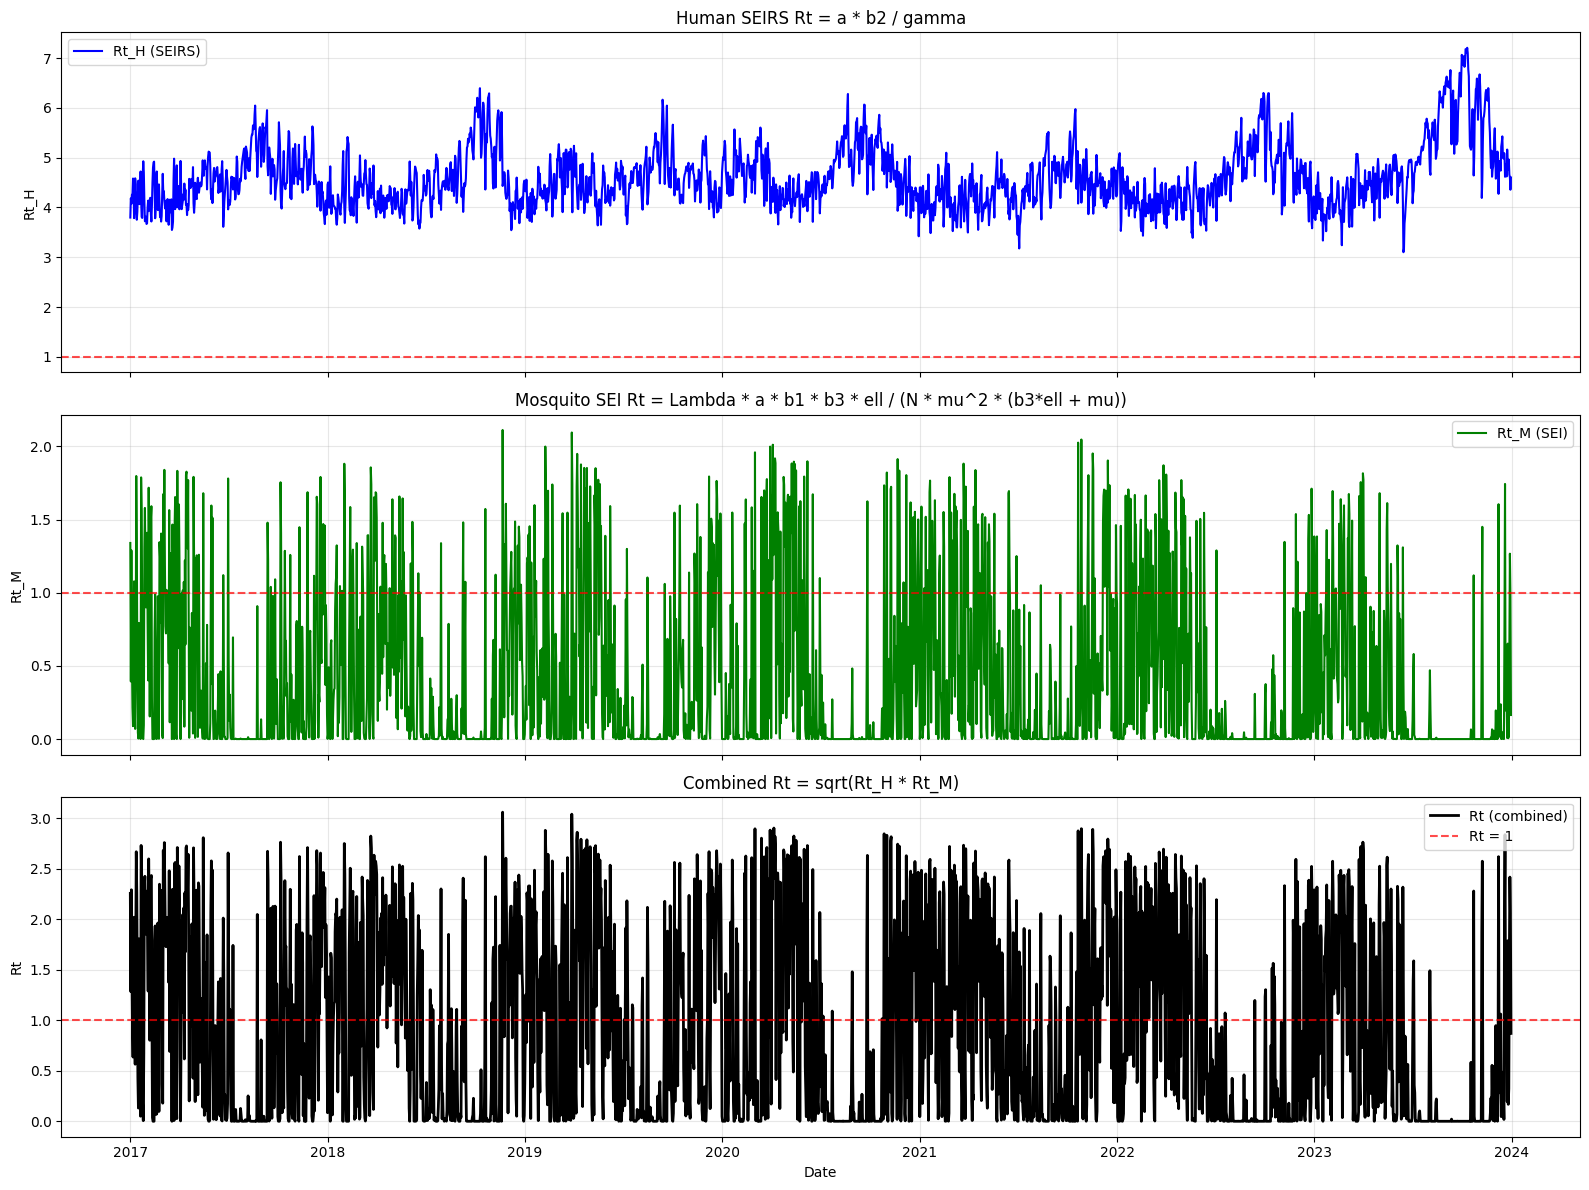

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_Rt["date"], df_Rt["Rt_H"], "b-", linewidth=1.5, label="Rt_H (SEIRS)")
axes[0].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Rt_H")
axes[0].set_title("Human SEIRS Rt = a * b2 / gamma")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_Rt["date"], df_Rt["Rt_M"], "g-", linewidth=1.5, label="Rt_M (SEI)")
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[1].set_ylabel("Rt_M")
axes[1].set_title("Mosquito SEI Rt = Lambda * a * b1 * b3 * ell / (N * mu^2 * (b3*ell + mu))")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_Rt["date"], df_Rt["Rt"], "k-", linewidth=2, label="Rt (combined)")
axes[2].axhline(1.0, color="red", linestyle="--", alpha=0.7, label="Rt = 1")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Rt")
axes[2].set_title("Combined Rt = sqrt(Rt_H * Rt_M)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
df_Rt = calculate_Rt(
    climate_data, pop_by_year, M_prime, 0.166667, 0.023333, gamma, T_prime, D1,
    B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2, A, B, C, DD, Tmin,
    R_L, tau_H, omega, optimal_temp_plasm, critical_max_temp_plasm,
    optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop
)
print(f"Rt range: [{df_Rt['Rt'].min():.3f}, {df_Rt['Rt'].max():.3f}]")
print(f"Rt_H range: [{df_Rt['Rt_H'].min():.3f}, {df_Rt['Rt_H'].max():.3f}]")
print(f"Rt_M range: [{df_Rt['Rt_M'].min():.3f}, {df_Rt['Rt_M'].max():.3f}]")
df_Rt.head()

Rt range: [0.000, 3.179]
Rt_H range: [0.804, 1.868]
Rt_M range: [0.000, 8.798]


,date,Rt_H,Rt_M,Rt,a(T),mu,b3,ell,b_rate,K,Lambda_eq,N
0,2017-01-01,0.984604,5.582045,2.344377,0.351649,0.104566,0.091943,0.341565,0.876114,403944.031058,37735.210524,8369
1,2017-01-02,1.084375,1.640242,1.333655,0.387282,0.119753,0.094033,0.322281,0.130417,241901.310741,15101.611616,8369
2,2017-01-03,1.055619,5.371413,2.381211,0.377012,0.121939,0.093683,0.307259,1.847525,486937.141281,55700.201910,8369
3,2017-01-04,1.103263,2.262897,1.580054,0.394028,0.122248,0.094138,0.320216,0.215531,279304.471922,21786.899341,8369
4,2017-01-05,1.098815,0.891332,0.989651,0.392440,0.178154,0.094123,0.189122,0.381086,328232.939015,39847.658709,8369


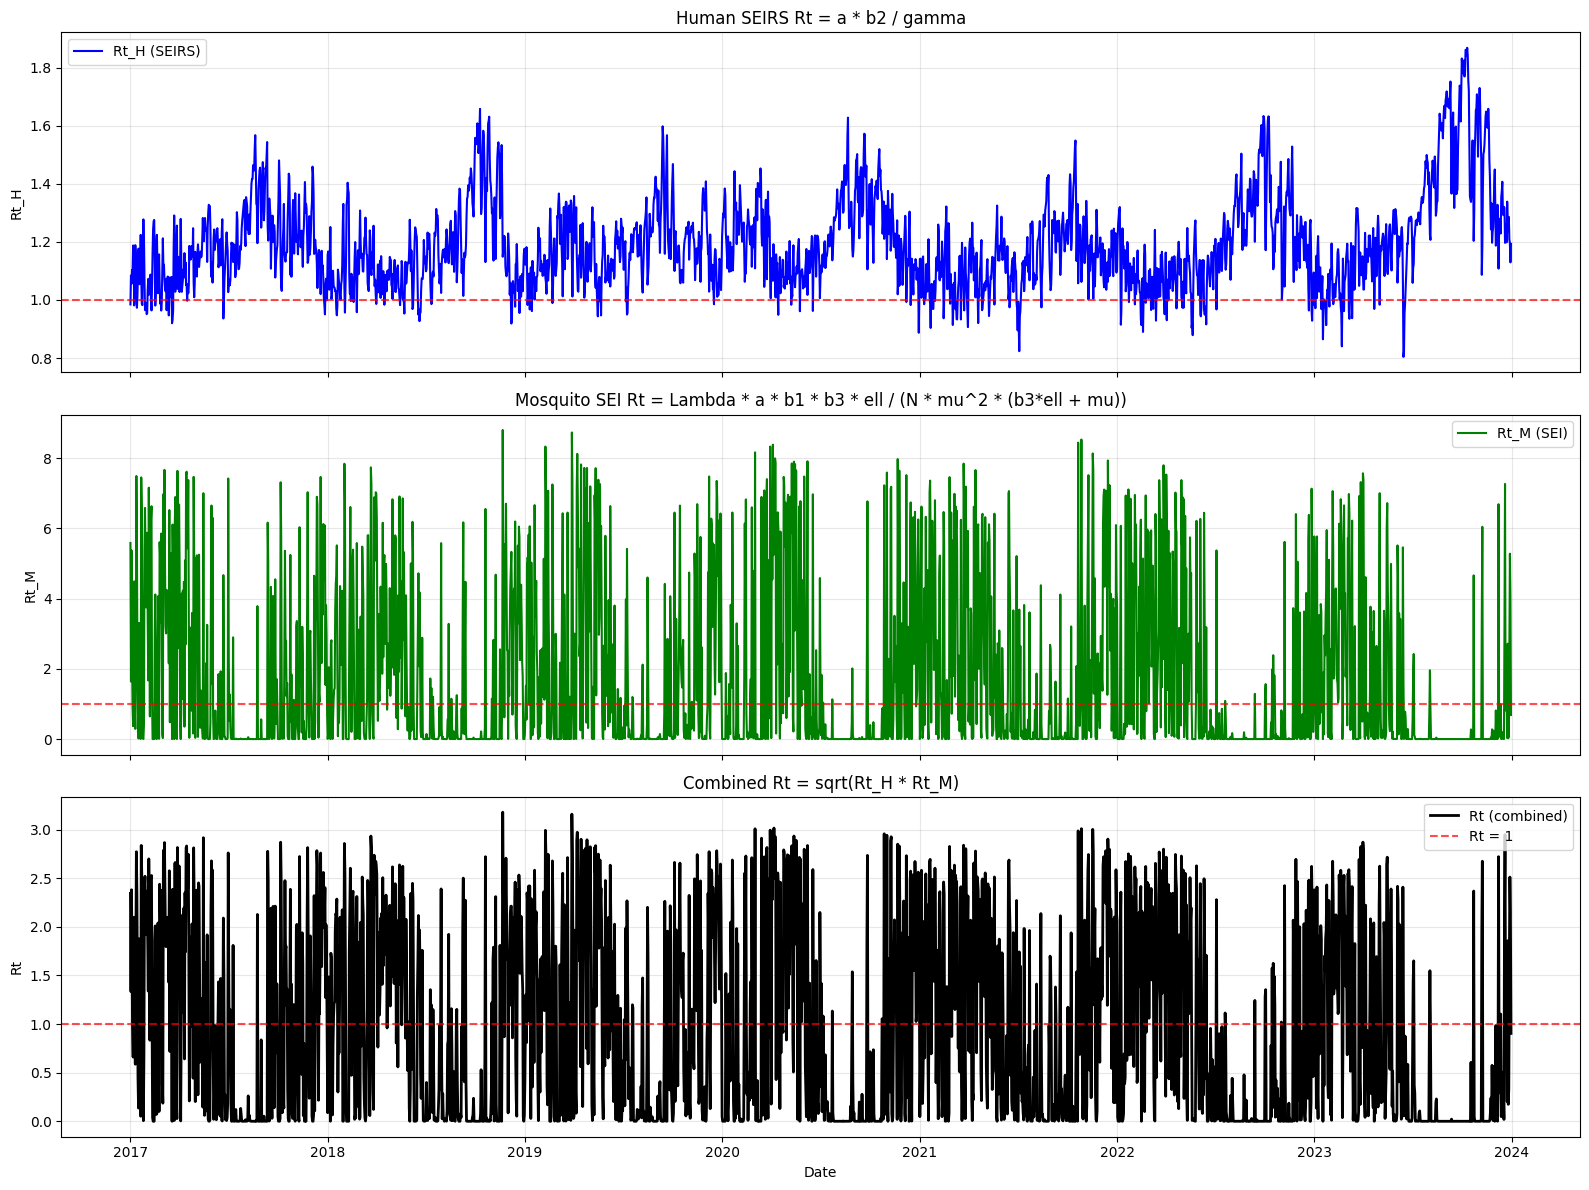

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df_Rt["date"], df_Rt["Rt_H"], "b-", linewidth=1.5, label="Rt_H (SEIRS)")
axes[0].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[0].set_ylabel("Rt_H")
axes[0].set_title("Human SEIRS Rt = a * b2 / gamma")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_Rt["date"], df_Rt["Rt_M"], "g-", linewidth=1.5, label="Rt_M (SEI)")
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[1].set_ylabel("Rt_M")
axes[1].set_title("Mosquito SEI Rt = Lambda * a * b1 * b3 * ell / (N * mu^2 * (b3*ell + mu))")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_Rt["date"], df_Rt["Rt"], "k-", linewidth=2, label="Rt (combined)")
axes[2].axhline(1.0, color="red", linestyle="--", alpha=0.7, label="Rt = 1")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Rt")
axes[2].set_title("Combined Rt = sqrt(Rt_H * Rt_M)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()